# VersaMammo Detection Boxes to MedSAM Segmentation

This notebook consumes the saved VersaMammo test-set predictions from `VersaMammo/downstream/Detection/metrics/<fold>/test_predictions.csv` and uses those boxes as prompts for MedSAM.

Pipeline:

1. Load saved detector predictions, without rerunning VersaMammo inference.
2. Pick the best fold by `test_metrics.json['map_50']`, or set a fold manually.
3. For each test image: confidence threshold `0.5`, NMS threshold `0.7`, keep top `K=3` boxes.
4. Run MedSAM once per retained box prompt.
5. Combine prompt masks into a union mask per image.
6. Compute Dice against the ground-truth `mask.png` in the VersaMammo-style test folder.
7. Save predicted masks, per-image metrics, summary metrics, and overlay visualizations.

In [1]:
from pathlib import Path
import csv
import json
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import io, transform
from skimage.color import gray2rgb
from skimage.util import img_as_ubyte
import torch
import torch.nn.functional as F
from torchvision.ops import nms

In [2]:
# -------------------------
# Configuration
# -------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "pipelines and experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

MEDSAM_ROOT = PROJECT_ROOT / "MedSAM"
VERSAMAMMO_ROOT = PROJECT_ROOT / "VersaMammo"
DETECTION_DIR = VERSAMAMMO_ROOT / "downstream" / "Detection"
METRICS_DIR = DETECTION_DIR / "metrics"
DATA_ROOT = VERSAMAMMO_ROOT / "datapre" / "segdetdata"

DATASET_PREFIX = "ZGT_VersaMammo"
FOLD = 4  # None = choose best fold by BEST_METRIC. Or set e.g. "ZGT_VersaMammo_fold4" / 4.
BEST_METRIC = "map_50"

CONFIDENCE_THRESHOLD = 0.5
NMS_THRESHOLD = 0.7
TOP_K = 3
DETECTOR_INPUT_SIZE = 512  # boxes in test_predictions.csv are in VersaMammo detector input coordinates

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
MEDSAM_CHECKPOINT = MEDSAM_ROOT / "work_dir" / "medsam_vit_b.pth"
OUTPUT_ROOT = PROJECT_ROOT / "pipelines and experiments" / "medsam_from_versamammo_outputs"

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()} | device: {DEVICE}")

Project root: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis
CUDA available: True | device: cuda:0


In [3]:
# Make MedSAM's local `segment_anything` package importable.
if str(MEDSAM_ROOT) not in sys.path:
    sys.path.insert(0, str(MEDSAM_ROOT))

from segment_anything import sam_model_registry

In [4]:
def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


def choose_best_fold(metrics_dir: Path, dataset_prefix: str, metric: str) -> str:
    candidates = []
    for metrics_path in sorted(metrics_dir.glob(f"{dataset_prefix}_fold*/test_metrics.json")):
        metrics = load_json(metrics_path)
        if metric in metrics:
            candidates.append((float(metrics[metric]), metrics_path.parent.name))
    if not candidates:
        raise FileNotFoundError(f"No fold metrics with key {metric!r} found under {metrics_dir}")
    candidates.sort(reverse=True)
    print("Available folds:")
    for value, fold_name in candidates:
        print(f"  {fold_name}: {metric}={value:.4f}")
    return candidates[0][1]


def normalize_fold_name(fold):
    if fold is None:
        return choose_best_fold(METRICS_DIR, DATASET_PREFIX, BEST_METRIC)
    if isinstance(fold, int) or str(fold).isdigit():
        return f"{DATASET_PREFIX}_fold{int(fold)}"
    return str(fold)


FOLD_NAME = normalize_fold_name(FOLD)
PREDICTION_CSV = METRICS_DIR / FOLD_NAME / "test_predictions.csv"
TEST_DIR = DATA_ROOT / FOLD_NAME / "Test"
OUT_DIR = OUTPUT_ROOT / FOLD_NAME
MASK_OUT_DIR = OUT_DIR / "pred_masks"
OVERLAY_OUT_DIR = OUT_DIR / "overlays"
METRICS_OUT = OUT_DIR / "medsam_segmentation_metrics.csv"
SUMMARY_OUT = OUT_DIR / "medsam_segmentation_summary.json"

print(f"Selected fold: {FOLD_NAME}")
print(f"Predictions: {PREDICTION_CSV}")
print(f"Test data: {TEST_DIR}")
print(f"Output: {OUT_DIR}")

Selected fold: ZGT_VersaMammo_fold4
Predictions: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/VersaMammo/downstream/Detection/metrics/ZGT_VersaMammo_fold4/test_predictions.csv
Test data: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/VersaMammo/datapre/segdetdata/ZGT_VersaMammo_fold4/Test
Output: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/pipelines and experiments/medsam_from_versamammo_outputs/ZGT_VersaMammo_fold4


In [5]:
def box_iou_np(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    boxes1 = np.asarray(boxes1, dtype=np.float32).reshape(-1, 4)
    boxes2 = np.asarray(boxes2, dtype=np.float32).reshape(-1, 4)
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)
    area1 = np.maximum(0, boxes1[:, 2] - boxes1[:, 0]) * np.maximum(0, boxes1[:, 3] - boxes1[:, 1])
    area2 = np.maximum(0, boxes2[:, 2] - boxes2[:, 0]) * np.maximum(0, boxes2[:, 3] - boxes2[:, 1])
    lt = np.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    rb = np.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = np.maximum(0, rb - lt)
    inter = wh[..., 0] * wh[..., 1]
    union = area1[:, None] + area2[None, :] - inter
    return np.divide(inter, union, out=np.zeros_like(inter), where=union > 0)


def dice_score(pred_mask: np.ndarray, gt_mask: np.ndarray) -> float:
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    denom = pred.sum() + gt.sum()
    if denom == 0:
        return 1.0
    return float(2 * np.logical_and(pred, gt).sum() / denom)


def load_predictions(csv_path: Path) -> dict[str, pd.DataFrame]:
    df = pd.read_csv(csv_path)
    required = {"image_name", "score", "x_min", "y_min", "x_max", "y_max"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Prediction CSV missing columns: {sorted(missing)}")
    return {name: group.copy() for name, group in df.groupby("image_name")}


def filter_boxes_for_medsam(pred_df: pd.DataFrame) -> pd.DataFrame:
    if pred_df is None or len(pred_df) == 0:
        return pd.DataFrame(columns=["score", "x_min", "y_min", "x_max", "y_max"])
    keep = pred_df[pred_df["score"] >= CONFIDENCE_THRESHOLD].copy()
    if len(keep) == 0:
        return keep
    boxes = torch.tensor(keep[["x_min", "y_min", "x_max", "y_max"]].to_numpy(), dtype=torch.float32)
    scores = torch.tensor(keep["score"].to_numpy(), dtype=torch.float32)
    keep_idx = nms(boxes, scores, NMS_THRESHOLD).cpu().numpy().tolist()
    keep = keep.iloc[keep_idx].sort_values("score", ascending=False).head(TOP_K)
    return keep.reset_index(drop=True)


def rescale_boxes_from_detector(boxes_512: np.ndarray, image_shape: tuple[int, int]) -> np.ndarray:
    h, w = image_shape[:2]
    scale = np.array([w / DETECTOR_INPUT_SIZE, h / DETECTOR_INPUT_SIZE, w / DETECTOR_INPUT_SIZE, h / DETECTOR_INPUT_SIZE], dtype=np.float32)
    boxes = boxes_512.astype(np.float32) * scale
    boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, w - 1)
    boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, h - 1)
    return boxes


def read_image_3c(path: Path) -> np.ndarray:
    image = io.imread(path)
    if image.ndim == 2:
        image = np.repeat(image[:, :, None], 3, axis=-1)
    elif image.shape[-1] == 4:
        image = image[:, :, :3]
    return image


def read_gt_mask(case_dir: Path, image_shape: tuple[int, int]) -> np.ndarray:
    mask_path = case_dir / "mask.png"
    if mask_path.exists():
        mask = io.imread(mask_path)
        if mask.ndim == 3:
            mask = mask[..., 0]
        return (mask > 0).astype(np.uint8)

    # Fallback only: this is not a true segmentation target, but prevents hard failure
    # if the VersaMammo detection tree contains boxes without masks.
    gt_boxes = np.load(case_dir / "bboxes.npy", allow_pickle=True).astype(np.float32).reshape(-1, 4)
    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    for x1, y1, x2, y2 in gt_boxes.astype(int):
        mask[max(0, y1):max(0, y2), max(0, x1):max(0, x2)] = 1
    return mask

In [6]:
@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :]

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed,
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )
    low_res_pred = torch.sigmoid(low_res_logits)
    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )
    low_res_pred = low_res_pred.squeeze(1).cpu().numpy()
    return (low_res_pred > 0.5).astype(np.uint8)


def encode_image_for_medsam(medsam_model, image_3c: np.ndarray, device: str):
    H, W = image_3c.shape[:2]
    img_1024 = transform.resize(
        image_3c,
        (1024, 1024),
        order=3,
        preserve_range=True,
        anti_aliasing=True,
    ).astype(np.uint8)
    img_1024 = (img_1024 - img_1024.min()) / np.clip(
        img_1024.max() - img_1024.min(),
        a_min=1e-8,
        a_max=None,
    )
    img_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)
    image_embedding = medsam_model.image_encoder(img_tensor)
    return image_embedding, H, W


def run_medsam_on_boxes(medsam_model, image_3c: np.ndarray, boxes_xyxy: np.ndarray, device: str) -> tuple[np.ndarray, list[np.ndarray]]:
    H, W = image_3c.shape[:2]
    if len(boxes_xyxy) == 0:
        return np.zeros((H, W), dtype=np.uint8), []

    image_embedding, H, W = encode_image_for_medsam(medsam_model, image_3c, device)
    box_1024 = boxes_xyxy / np.array([W, H, W, H], dtype=np.float32) * 1024
    prompt_masks = medsam_inference(medsam_model, image_embedding, box_1024, H, W)
    union_mask = np.any(prompt_masks > 0, axis=0).astype(np.uint8)
    return union_mask, [m.astype(np.uint8) for m in prompt_masks]

In [7]:
def overlay_masks(image_3c, gt_mask, pred_mask, boxes, scores, title, out_path):
    image = image_3c
    if image.dtype != np.uint8:
        image = img_as_ubyte((image - image.min()) / np.clip(image.max() - image.min(), 1e-8, None))

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image, cmap="gray")

    gt_rgba = np.zeros((*gt_mask.shape, 4), dtype=np.float32)
    gt_rgba[..., 1] = 1.0
    gt_rgba[..., 3] = gt_mask.astype(bool) * 0.35
    ax.imshow(gt_rgba)

    pred_rgba = np.zeros((*pred_mask.shape, 4), dtype=np.float32)
    pred_rgba[..., 0] = 1.0
    pred_rgba[..., 3] = pred_mask.astype(bool) * 0.35
    ax.imshow(pred_rgba)

    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = box.tolist()
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 4), f"{score:.2f}", color="black", fontsize=8, bbox={"facecolor": "yellow", "alpha": 0.8, "pad": 1})

    ax.set_title(title)
    ax.set_axis_off()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=160)
    plt.close(fig)

In [8]:
if not MEDSAM_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"MedSAM checkpoint not found: {MEDSAM_CHECKPOINT}\n"
        "Update MEDSAM_CHECKPOINT in the config cell."
    )

print(f"Loading MedSAM checkpoint: {MEDSAM_CHECKPOINT}")
medsam_model = sam_model_registry["vit_b"](checkpoint=str(MEDSAM_CHECKPOINT)).to(DEVICE)
medsam_model.eval()
print("MedSAM loaded.")

Loading MedSAM checkpoint: /export/home/rstanciu/FM_thesis_Razvan/FM_thesis/MedSAM/work_dir/medsam_vit_b.pth
MedSAM loaded.


In [9]:
predictions_by_image = load_predictions(PREDICTION_CSV)
case_dirs = sorted([p for p in TEST_DIR.iterdir() if p.is_dir()])
print(f"Loaded predictions for {len(predictions_by_image)} images")
print(f"Found {len(case_dirs)} test cases")

Loaded predictions for 26 images
Found 26 test cases


In [10]:
MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []

for idx, case_dir in enumerate(case_dirs, start=1):
    image_name = case_dir.name
    image_path = case_dir / "img.jpg"
    image_3c = read_image_3c(image_path)
    gt_mask = read_gt_mask(case_dir, image_3c.shape)

    filtered = filter_boxes_for_medsam(predictions_by_image.get(image_name))
    boxes_512 = filtered[["x_min", "y_min", "x_max", "y_max"]].to_numpy(dtype=np.float32) if len(filtered) else np.zeros((0, 4), dtype=np.float32)
    boxes_raw = rescale_boxes_from_detector(boxes_512, image_3c.shape)
    scores = filtered["score"].to_numpy(dtype=np.float32) if len(filtered) else np.array([], dtype=np.float32)

    pred_mask, prompt_masks = run_medsam_on_boxes(medsam_model, image_3c, boxes_raw, DEVICE)
    dice = dice_score(pred_mask, gt_mask)

    io.imsave(MASK_OUT_DIR / f"{image_name}_pred_union.png", (pred_mask * 255).astype(np.uint8), check_contrast=False)
    for prompt_idx, mask in enumerate(prompt_masks):
        io.imsave(MASK_OUT_DIR / f"{image_name}_prompt{prompt_idx + 1}.png", (mask * 255).astype(np.uint8), check_contrast=False)

    overlay_masks(
        image_3c=image_3c,
        gt_mask=gt_mask,
        pred_mask=pred_mask,
        boxes=boxes_raw,
        scores=scores,
        title=f"{image_name} | Dice={dice:.3f} | prompts={len(boxes_raw)}",
        out_path=OVERLAY_OUT_DIR / f"{image_name}.png",
    )

    rows.append({
        "image_name": image_name,
        "dice": dice,
        "num_prompts": int(len(boxes_raw)),
        "max_score": float(scores.max()) if len(scores) else 0.0,
        "gt_area": int(gt_mask.astype(bool).sum()),
        "pred_area": int(pred_mask.astype(bool).sum()),
    })

    if idx % 5 == 0 or idx == len(case_dirs):
        print(f"Processed {idx}/{len(case_dirs)} images")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(METRICS_OUT, index=False)
summary = {
    "fold": FOLD_NAME,
    "num_images": int(len(metrics_df)),
    "mean_dice": float(metrics_df["dice"].mean()) if len(metrics_df) else 0.0,
    "median_dice": float(metrics_df["dice"].median()) if len(metrics_df) else 0.0,
    "std_dice": float(metrics_df["dice"].std(ddof=1)) if len(metrics_df) > 1 else 0.0,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "nms_threshold": NMS_THRESHOLD,
    "top_k": TOP_K,
    "detector_input_size": DETECTOR_INPUT_SIZE,
}
with open(SUMMARY_OUT, "w") as f:
    json.dump(summary, f, indent=2)

summary

Processed 5/26 images
Processed 10/26 images
Processed 15/26 images
Processed 20/26 images
Processed 25/26 images
Processed 26/26 images


{'fold': 'ZGT_VersaMammo_fold4',
 'num_images': 26,
 'mean_dice': 0.4806320312947162,
 'median_dice': 0.5460061786232253,
 'std_dice': 0.3014058825103301,
 'confidence_threshold': 0.5,
 'nms_threshold': 0.7,
 'top_k': 3,
 'detector_input_size': 512}

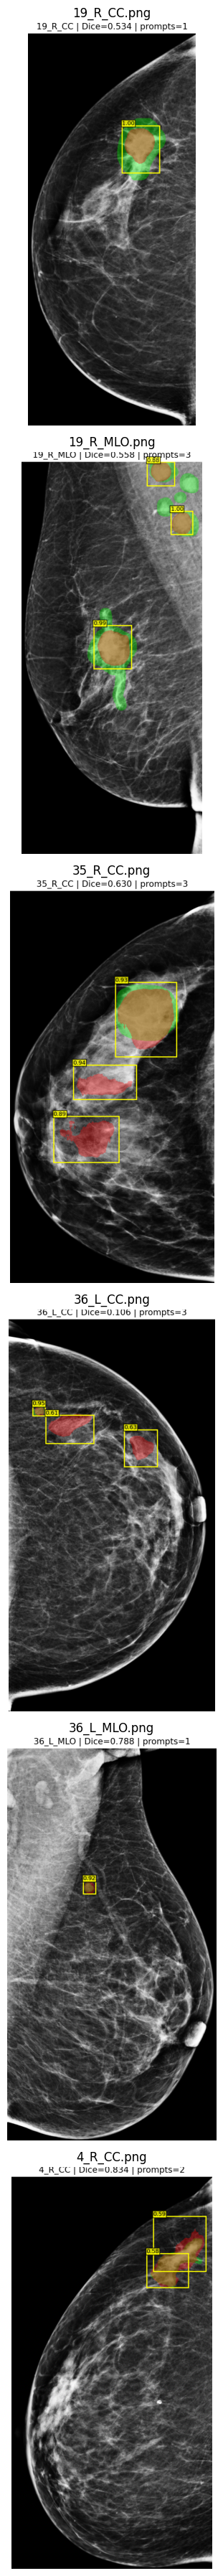

In [11]:
# Show the first few generated overlays inside the notebook.
preview_paths = sorted(OVERLAY_OUT_DIR.glob("*.png"))[:6]
if not preview_paths:
    print("No overlays generated.")
else:
    n = len(preview_paths)
    fig, axes = plt.subplots(n, 1, figsize=(10, 6 * n))
    if n == 1:
        axes = [axes]
    for ax, path in zip(axes, preview_paths):
        ax.imshow(io.imread(path))
        ax.set_title(path.name)
        ax.set_axis_off()
    plt.tight_layout()